# COMPROBAR DEPENDENCIAS 

In [2]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

print("DuckDB:", duckdb.__version__)
print("Pandas:", pd.__version__)


DuckDB: 1.5.4
Pandas: 3.0.3


# Challenge Meli 

## Estructura del análisis

| Sección | Contenido |
|---|---|
| 1 | Setup e importaciones |
| 2 | Carga y limpieza de datos (Wide → Long) |
| 3 | Carga a DuckDB |
| 4 | Query 1 — Indicadores por Año y País |
| 5 | Query 2 — Crecimiento YoY desde 2010 |
| 6 | Visualizaciones |
| 7 | Conclusiones y relación con MercadoLibre |


# 1. Setup e importaciones 

In [7]:
import pandas as pd
import duckdb
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

FILE_CELULAR  = '../Data/BASE_CELULAR.xls'
FILE_INTERNET = '../Data/BASE_INTERNET.xlsx'
FILE_POBLACION = '../Data/BASE_POBLACION.xls'

print('Librerías cargadas')



Librerías cargadas


# 2. Carga y limpieza de datos 

1. Para este paso tenemos que tener en cuenta que los xls menajan los datos en un formato WIDE, en el cual cada año se tiene en una columna. Para trabajar esta data en SQL, necesitamos transformar los datos de WIDE a tipo LONG(País, año, valor).
2. **Agregados regionales:** 49 códigos como `AFE`, `ARB`, `EUU` son sumas regionales, no países. Se excluyen usando la hoja `Metadata - Countries` (campo `Income_Group = 'Agregados'`).
3. **NULLs en 2021:** el 72 % de los países no tiene dato de internet en 2021 porque el World Bank aún no lo había publicado al momento de la extracción. Se conservan como NULL, no se imputan.
4. **Archivo de población (File 3):** contiene datos desde 1960. Solo se usa 2000–2021 para alinear con los otros indicadores.



def leer world bak : Esta función lee un archivo World Bank en formato wide , salta las primeras 3 filas de metadatos del banco mundial y retorna un dataframe limpio.

def wide a long : Con la operación Melt, las columnas de los años la transformamos a una variable que nos dará los años en filas por país.


In [ ]:
def leer_world_bank(path, engine=None):
    kw = {'skiprows': 3, 'header': 0, 'sheet_name': 'Data'}
    if engine:
        kw['engine'] = engine
    df = pd.read_excel(path, **kw)
    return df.dropna(how='all')  


def wide_a_long(df, nombre_valor):
    cols_id   = ['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code']
    cols_anio = [c for c in df.columns if str(c).isdigit()]

    long = df[cols_id + cols_anio].melt(
        id_vars    = cols_id,
        var_name   = 'year',
        value_name = nombre_valor
    )
    long['year'] = long['year'].astype(int)

    return long.rename(columns={
        'Country Name'   : 'country_name',
        'Country Code'   : 'country_code',
        'Indicator Name' : 'indicator_name',
        'Indicator Code' : 'indicator_code',
    })


raw_celular   = leer_world_bank(FILE_CELULAR,   engine='xlrd')
raw_internet  = leer_world_bank(FILE_INTERNET)
raw_poblacion = leer_world_bank(FILE_POBLACION, engine='xlrd')

# Leer metadatos de países (para filtrar agregados y obtener región)
meta = pd.read_excel(FILE_CELULAR, engine='xlrd', sheet_name='Metadata - Countries')
meta = meta.rename(columns={
    'Country Name' : 'country_name',
    'Country Code' : 'country_code',
    'Region'       : 'region',
    'Income_Group' : 'income_group',
})

print(f'File 1 (celular)   : {raw_celular.shape[0]} países, {raw_celular.shape[1]-4} años')
print(f'File 2 (internet)  : {raw_internet.shape[0]} países, {raw_internet.shape[1]-4} años')
print(f'File 3 (población) : {raw_poblacion.shape[0]} países, {raw_poblacion.shape[1]-4} años')
print(f'Metadata           : {len(meta)} registros')


File 1 (celular)   : 266 países, 22 años
File 2 (internet)  : 266 países, 22 años
File 3 (población) : 266 países, 62 años
Metadata           : 266 registros


## Convertir cada xls a long 

Una vez tenemos los formatos Long definidos, transformemos las tablas, y hagamos un Left Join (merge en pandas) desde 2000 a 2021 para unir estas 3 tablas en una sola, sin perder datos en caso tal que falte algun valor en una fila. 

In [10]:
long_celular   = wide_a_long(raw_celular,   'mobile_subscriptions')
long_internet  = wide_a_long(raw_internet,  'internet_pct')
long_poblacion = wide_a_long(raw_poblacion, 'population')


world_indicators = (
    long_internet[['country_name','country_code','year','internet_pct']]
    .merge(long_celular[['country_code','year','mobile_subscriptions']],
           on=['country_code','year'], how='left')
    .merge(long_poblacion[['country_code','year','population']],
           on=['country_code','year'], how='left')
)

# Resumen de calidad
agregados = meta[meta['income_group']=='Agregados']['country_code'].tolist()

print(f'Tabla unificada (world_indicators):')
print(f'  Total filas       : {len(world_indicators):,}')
print(f'  Países totales    : {world_indicators["country_code"].nunique()}')
print(f'  Agregados a excl. : {len(agregados)}')
print(f'  Países reales     : {world_indicators["country_code"].nunique() - len(agregados)}')
print(f'  Rango de años     : {world_indicators["year"].min()} – {world_indicators["year"].max()}')
print()
print('NULLs por indicador:')
print(world_indicators[['internet_pct','mobile_subscriptions','population']].isna().sum())


Tabla unificada (world_indicators):
  Total filas       : 5,852
  Países totales    : 266
  Agregados a excl. : 49
  Países reales     : 217
  Rango de años     : 2000 – 2021

NULLs por indicador:
internet_pct            689
mobile_subscriptions    359
population               22
dtype: int64


# 3. Cargar a DUCKDB

DuckDB permite ejecutar SQL directamente sobre DataFrames de pandas sin necesidad de un servidor.
Se registran las dos tablas como vistas en memoria.


In [ ]:
# Crear conexión en memoria
con = duckdb.connect()

# Registrar DataFrames como tablas SQL
con.register('world_indicators',   world_indicators)
con.register('countries_metadata', meta)

# Verificar tablas 
tablas = con.execute("SHOW TABLES").df()
print('Tablas registradas en DuckDB:')
print(tablas)

print('\nVista previa — world_indicators:')
con.execute("""
    SELECT *
    FROM world_indicators
    WHERE country_code = 'COL'
    LIMIT 5
""").df()


Tablas registradas en DuckDB:
                 name
0  countries_metadata
1    world_indicators

Vista previa — world_indicators:


,country_name,country_code,year,internet_pct,mobile_subscriptions,population
0,Colombia,COL,2000,2.207533,2256801.0,39215135.0
1,Colombia,COL,2001,2.854200,3265261.0,39837875.0
2,Colombia,COL,2002,4.600000,4596594.0,40454050.0
3,Colombia,COL,2003,7.388924,6186206.0,41057687.0
4,Colombia,COL,2004,9.118690,10400578.0,41648268.0


# 4. Query 1: Indicadores por Año y País

Este query busca : ver por Año y País los indicadores de % personas que usan internet, suscripciones a telefonía celular móvil y población total. 

Para esto haremos este paso a paso : 
- `INNER JOIN` con `countries_metadata` para poder filtrar agregados regionales y enriquecer con región e income group.
- `ROUND(internet_pct, 2)` para presentar el porcentaje con precisión legible.
- `WHERE income_group != 'Agregados'` excluye los 49 códigos regionales del World Bank.
- Orden: año ascendente, luego país alfabético (facilita lectura y validación).

In [16]:
SQL_QUERY_1 = """
SELECT
    t.year                              AS anio,
    t.country_name                      AS pais,
    t.country_code                      AS codigo_pais,
    m.region,
    m.income_group,
    ROUND(t.internet_pct, 2)            AS pct_personas_internet,
    t.mobile_subscriptions              AS suscripciones_celular,
    t.population                        AS poblacion_total

FROM world_indicators t
INNER JOIN countries_metadata m
    ON t.country_code = m.country_code

WHERE m.income_group != 'Agregados'

ORDER BY
    t.year        ASC,
    t.country_name ASC
"""

resultado_q1 = con.execute(SQL_QUERY_1).df()

print(f'Query 1 — filas: {len(resultado_q1):,} | países únicos: {resultado_q1["codigo_pais"].nunique()}')
resultado_q1.head(10)


Query 1 — filas: 4,774 | países únicos: 217


,anio,pais,codigo_pais,region,income_group,pct_personas_internet,suscripciones_celular,poblacion_total
0,2000,Afganistán,AFG,Asia meridional,Países de ingreso bajo,NaN,0.0,19542982.0
1,2000,Albania,ALB,Europa y Asia central (excluido altos ingresos),Ingreso mediano alto,0.11,29791.0,3089027.0
2,2000,Alemania,DEU,NaN,Ingreso alto,30.22,48202000.0,82211508.0
3,2000,Andorra,AND,NaN,Ingreso alto,10.54,23543.0,66097.0
4,2000,Angola,AGO,África al sur del Sahara (excluido altos ingre...,Países de ingreso mediano bajo,0.11,25806.0,16394062.0
5,2000,Antigua y Barbuda,ATG,NaN,Ingreso alto,6.48,22000.0,75055.0
6,2000,Arabia Saudita,SAU,NaN,Ingreso alto,2.21,1375881.0,21547390.0
7,2000,Argelia,DZA,Oriente Medio y Norte de África (excluido alto...,Países de ingreso mediano bajo,0.49,86000.0,30774621.0
8,2000,Argentina,ARG,América Latina y el Caribe (excluido altos ing...,Ingreso mediano alto,7.04,6487950.0,37070774.0
9,2000,Armenia,ARM,Europa y Asia central (excluido altos ingresos),Ingreso mediano alto,1.30,17486.0,3168523.0


In [13]:
cobertura_anual = con.execute("""
    SELECT
        t.year AS anio,
        COUNT(*) AS total_paises,

        -- internet
        SUM(CASE WHEN t.internet_pct IS NULL THEN 1 ELSE 0 END) AS sin_internet,
        ROUND(SUM(CASE WHEN t.internet_pct IS NULL THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1) AS pct_sin_internet,

        -- celular
        SUM(CASE WHEN t.mobile_subscriptions IS NULL THEN 1 ELSE 0 END) AS sin_celular,
        ROUND(SUM(CASE WHEN t.mobile_subscriptions IS NULL THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1) AS pct_sin_celular,

        -- población
        SUM(CASE WHEN t.population IS NULL THEN 1 ELSE 0 END) AS sin_poblacion,
        ROUND(SUM(CASE WHEN t.population IS NULL THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1) AS pct_sin_poblacion

    FROM world_indicators t
    INNER JOIN countries_metadata m ON t.country_code = m.country_code
    WHERE m.income_group != 'Agregados'
    GROUP BY t.year
    ORDER BY t.year
""").df()

print("Cobertura de datos por año (% de países SIN dato):")
cobertura_anual

Cobertura de datos por año (% de países SIN dato):


,anio,total_paises,sin_internet,pct_sin_internet,sin_celular,pct_sin_celular,sin_poblacion,pct_sin_poblacion
0,2000,217,21.0,9.7,12.0,5.5,0.0,0.0
1,2001,217,18.0,8.3,12.0,5.5,0.0,0.0
2,2002,217,15.0,6.9,11.0,5.1,0.0,0.0
3,2003,217,21.0,9.7,11.0,5.1,0.0,0.0
4,2004,217,18.0,8.3,10.0,4.6,0.0,0.0
5,2005,217,17.0,7.8,13.0,6.0,0.0,0.0
6,2006,217,18.0,8.3,16.0,7.4,0.0,0.0
7,2007,217,13.0,6.0,13.0,6.0,0.0,0.0
8,2008,217,15.0,6.9,15.0,6.9,0.0,0.0
9,2009,217,15.0,6.9,13.0,6.0,0.0,0.0


Se identificaron dos patrones de NaN con causas distintas:

**NaN en `pct_personas_internet`** — países como Afganistán puede que en dicho año no tenían
infraestructura de internet o simplemente no reportaron dato al World Bank. 
para 2021 porque el World Bank no había publicado esa información.

**NaN en `region`** — corresponde exclusivamente a países de ingreso alto
(Alemania, Arabia Saudita, Andorra, etc.) y a países no clasificados.
El World Bank no les asigna región geográfica en su taxonomía. No es
un error del join ni de los datos.

Se evaluaron tres alternativas de tratamiento:

- **`dropna`** — descartado. Eliminaría países enteros por no tener dato
en un año específico, reduciendo la cobertura sin justificación válida.
- **`fillna`** — descartado. No existe un valor neutro correcto. Usar 0
distorsionaría los promedios y el crecimiento YoY.
- **`interpolate`** — descartado. Solo válida cuando el dato ocurrió pero
no fue registrado. Aquí los NaN existen porque el dato no estaba
disponible en la fuente, no porque no se haya registrado.

**Decisión final: conservar los NaN.**
Los valores nulos en este dataset son informativos, no errores.


# Cómo opera en LATAM estos indicadores teniendo en cuenta la región de operación de MELI ? 

In [14]:
LATAM = ['ARG','BOL','BRA','CHL','COL','CRI','CUB','DOM','ECU',
         'GTM','HND','MEX','NIC','PAN','PER','PRY','SLV','URY','VEN']

latam_2020 = resultado_q1[
    (resultado_q1['anio'] == 2020) &
    (resultado_q1['codigo_pais'].isin(LATAM))
].sort_values('pct_personas_internet', ascending=False)

print('LATAM — año 2020 (ordenado por % internet)')
latam_2020[['pais','anio','pct_personas_internet','suscripciones_celular','poblacion_total']]

LATAM — año 2020 (ordenado por % internet)


,pais,anio,pct_personas_internet,suscripciones_celular,poblacion_total
4377,Chile,2020,88.30,25068249.0,19300315.0
4549,Uruguay,2020,86.10,4551276.0,3429086.0
4348,Argentina,2020,85.50,202008855.0,45376763.0
4366,Brasil,2020,81.34,205834781.0,213196304.0
4386,Costa Rica,2020,80.53,7512370.0,5123105.0
4508,República Dominicana,2020,76.90,8989587.0,10999664.0
4388,Cuba,2020,74.00,6661763.0,11300698.0
4495,Paraguay,2020,73.96,7865050.0,6618695.0
4479,México,2020,71.97,122898392.0,125998302.0
4394,Ecuador,2020,70.70,15485366.0,17588595.0


Guardemos esta informacion en un csv

In [15]:
resultado_q1.to_csv('../Outputs/query1_indicadores_anio_pais.csv', index=False)
print('Archivo guardado: outputs/query1_indicadores_anio_pais.csv ✓')

Archivo guardado: outputs/query1_indicadores_anio_pais.csv ✓


# 5. Query 2: Crecimiento desde el 2010


- **`LAG(valor) OVER (PARTITION BY country_code ORDER BY year)`**: función de ventana que devuelve el valor del año anterior *dentro del mismo país*. Sin el `PARTITION BY`, tomaría el año anterior del dataset global (otro país).
- **`NULLIF(denominador, 0)`**: evita división por cero. Si el año anterior era 0, devuelve NULL en lugar de error.
- **CTE (`WITH base AS`)**: separa la lógica en dos pasos. Primero se calculan los LAGs; luego se aplica el filtro de año y la fórmula de crecimiento. Más legible que subqueries anidados.
- **NULL en 2010**: es semánticamente correcto. El challenge pide datos desde 2010, por lo que no existe un año 2009 para calcular el crecimiento inicial. No es un error de datos.
- **"No pueden faltar países"**: todos los países aparecen aunque tengan NULLs en algunos años, porque el filtro `year >= 2010` actúa sobre la tabla ya procesada con los LAGs.



 Fórmula : (valor_actual - valor_anterior) / valor_anterior * 100

In [ ]:
SQL_QUERY_2 = """

WITH base AS (
    SELECT
        t.country_code,
        t.country_name,
        m.region,
        m.income_group,
        t.year,

        -- Valores del año actual
        t.internet_pct,
        t.mobile_subscriptions,
        t.population,

        -- Valores del año anterior (por país, no global)
        LAG(t.internet_pct)         OVER (PARTITION BY t.country_code ORDER BY t.year) AS internet_pct_prev,
        LAG(t.mobile_subscriptions) OVER (PARTITION BY t.country_code ORDER BY t.year) AS mobile_prev,
        LAG(t.population)           OVER (PARTITION BY t.country_code ORDER BY t.year) AS population_prev

    FROM world_indicators t
    INNER JOIN countries_metadata m
        ON t.country_code = m.country_code

    WHERE m.income_group != 'Agregados'
)

SELECT
    country_name                                  AS pais,
    country_code                                  AS codigo_pais,
    region,
    year                                          AS anio,

    -- Valores actuales
    ROUND(internet_pct, 2)                        AS pct_internet,
    mobile_subscriptions                          AS suscripciones_celular,
    population                                    AS poblacion,

    -- YoY — NULL en 2010 es correcto (no existe 2009 en el dataset)
    ROUND((internet_pct - internet_pct_prev)
          / NULLIF(internet_pct_prev, 0) * 100, 2)    AS yoy_internet_pct,

    ROUND((mobile_subscriptions - mobile_prev)
          / NULLIF(mobile_prev, 0) * 100, 2)           AS yoy_celular_pct,

    ROUND((population - population_prev)
          / NULLIF(population_prev, 0) * 100, 2)       AS yoy_poblacion_pct

FROM base
WHERE year >= 2010
ORDER BY country_name, year
"""

resultado_q2 = con.execute(SQL_QUERY_2).df()

print(f'Query 2 — filas: {len(resultado_q2):,} | países únicos: {resultado_q2["codigo_pais"].nunique()}')
resultado_q2.head(10)


Query 2 — filas: 2,604 | países únicos: 217


,pais,codigo_pais,region,anio,pct_internet,suscripciones_celular,poblacion,yoy_internet_pct,yoy_celular_pct,yoy_poblacion_pct
0,Afganistán,AFG,Asia meridional,2010,4.00,10215840.0,28189672.0,12.68,-2.71,2.94
1,Afganistán,AFG,Asia meridional,2011,5.00,13797879.0,29249157.0,25.00,35.06,3.76
2,Afganistán,AFG,Asia meridional,2012,5.45,15340115.0,30466479.0,9.09,11.18,4.16
3,Afganistán,AFG,Asia meridional,2013,5.90,16807156.0,31541209.0,8.17,9.56,3.53
4,Afganistán,AFG,Asia meridional,2014,7.00,18407168.0,32716210.0,18.64,9.52,3.73
5,Afganistán,AFG,Asia meridional,2015,8.26,19709038.0,33753499.0,18.00,7.07,3.17
6,Afganistán,AFG,Asia meridional,2016,11.00,21602982.0,34636207.0,33.17,9.61,2.62
7,Afganistán,AFG,Asia meridional,2017,13.50,23929713.0,35643418.0,22.73,10.77,2.91
8,Afganistán,AFG,Asia meridional,2018,16.80,21976355.0,36686784.0,24.44,-8.16,2.93
9,Afganistán,AFG,Asia meridional,2019,17.60,22580071.0,37769499.0,4.76,2.75,2.95


Un YoY negativo simplemente significa que el indicador bajó ese año respecto al anterior. 

## Cómo está ese crecimiento de indicadores en colombia ? 

In [19]:
colombia = resultado_q2[resultado_q2['codigo_pais'] == 'COL']
colombia


,pais,codigo_pais,region,anio,pct_internet,suscripciones_celular,poblacion,yoy_internet_pct,yoy_celular_pct,yoy_poblacion_pct
480,Colombia,COL,América Latina y el Caribe (excluido altos ing...,2010,36.50,44477653.0,44816108.0,21.67,5.50,1.13
481,Colombia,COL,América Latina y el Caribe (excluido altos ing...,2011,40.35,46200421.0,45308899.0,10.55,3.87,1.10
482,Colombia,COL,América Latina y el Caribe (excluido altos ing...,2012,48.98,49066359.0,45782417.0,21.39,6.20,1.05
483,Colombia,COL,América Latina y el Caribe (excluido altos ing...,2013,51.70,50295114.0,46237930.0,5.55,2.50,0.99
484,Colombia,COL,América Latina y el Caribe (excluido altos ing...,2014,52.57,55330272.0,46677947.0,1.68,10.01,0.95
485,Colombia,COL,América Latina y el Caribe (excluido altos ing...,2015,55.90,57327470.0,47119728.0,6.34,3.61,0.95
486,Colombia,COL,América Latina y el Caribe (excluido altos ing...,2016,58.14,58684924.0,47625955.0,3.99,2.37,1.07
487,Colombia,COL,América Latina y el Caribe (excluido altos ing...,2017,62.26,62220014.0,48351671.0,7.09,6.02,1.52
488,Colombia,COL,América Latina y el Caribe (excluido altos ing...,2018,64.13,64513977.0,49276961.0,3.00,3.69,1.91
489,Colombia,COL,América Latina y el Caribe (excluido altos ing...,2019,65.01,66283175.0,50187406.0,1.37,2.74,1.85


Guardar csv de la query 2 : 

In [ ]:
resultado_q2.to_csv('../outputs/query2_crecimiento_yoy.csv', index=False)
print('Archivo guardado: outputs/query2_crecimiento_yoy.csv ')


Archivo guardado: outputs/query2_crecimiento_yoy.csv ✓


# 6. Visualizaciones

## GRÁFICA 1 : EVOLUCIÓN DE % DE INTERNET EN LATAM 2010 - 2021

In [24]:
HIGHLIGHT = ['BRA','MEX','COL','ARG','CHL']
COLORES   = {
    'BRA': '#FFB300',
    'MEX': '#E53935',
    'COL': '#1E88E5',
    'ARG': '#43A047',
    'CHL': '#8E24AA',
}
latam_q2 = resultado_q2[resultado_q2['codigo_pais'].isin(LATAM)].copy()


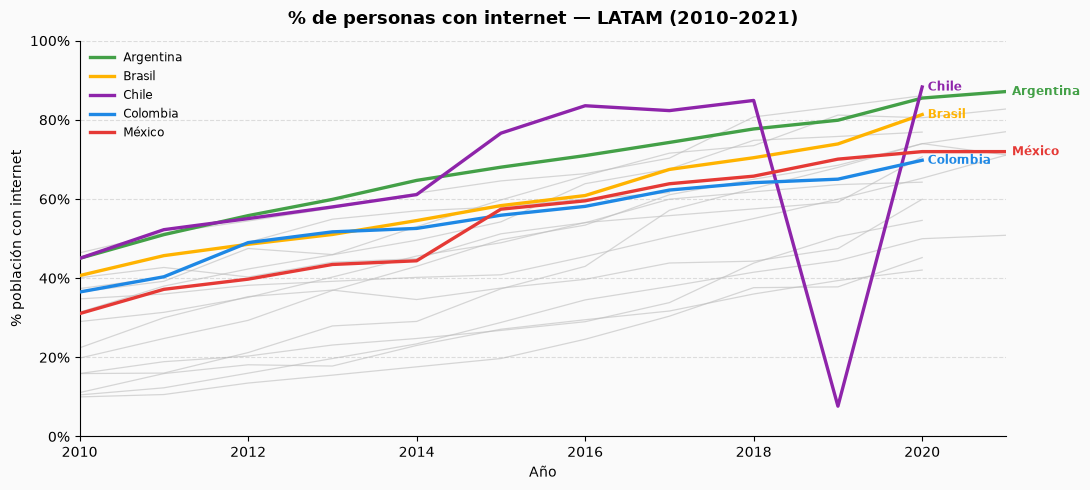

In [25]:

fig, ax = plt.subplots(figsize=(11, 5))
fig.patch.set_facecolor('#FAFAFA')
ax.set_facecolor('#FAFAFA')

for code in LATAM:
    df_c = latam_q2[latam_q2['codigo_pais'] == code].dropna(subset=['pct_internet'])
    if df_c.empty:
        continue
    if code in HIGHLIGHT:
        ax.plot(df_c['anio'], df_c['pct_internet'],
                color=COLORES[code], linewidth=2.4, zorder=3,
                label=df_c['pais'].iloc[0])
        ax.annotate(df_c['pais'].iloc[0],
                    xy=(df_c['anio'].iloc[-1], df_c['pct_internet'].iloc[-1]),
                    xytext=(4, 0), textcoords='offset points',
                    fontsize=8.5, color=COLORES[code], va='center', fontweight='bold')
    else:
        ax.plot(df_c['anio'], df_c['pct_internet'],
                color='#BDBDBD', linewidth=0.9, zorder=1, alpha=0.6)

ax.set_title('% de personas con internet — LATAM (2010–2021)',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Año', fontsize=10)
ax.set_ylabel('% población con internet', fontsize=10)
ax.set_xlim(2010, 2021)
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.spines[['top','right']].set_visible(False)
ax.legend(loc='upper left', fontsize=8.5, framealpha=0)
plt.tight_layout()
plt.savefig('../outputs/grafica1_internet_latam.png', dpi=150, bbox_inches='tight')
plt.show()


## GRÁFICA 2 : CRECIMIENTO YOY EN INTERNET POR PAIS 

In [ ]:

pivot = latam_q2[latam_q2['anio'] >= 2011].pivot_table(
    index='pais', columns='anio', values='yoy_internet_pct'
)
# Ordenar por promedio de crecimiento (más dinámicos arriba)
pivot = pivot.loc[pivot.mean(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(13, 8))
fig.patch.set_facecolor('#FAFAFA')

sns.heatmap(
    pivot, annot=True, fmt='.1f', cmap='YlOrRd',
    linewidths=0.4, linecolor='#EEEEEE',
    cbar_kws={'label': 'Crecimiento YoY (%)', 'shrink': 0.6},
    ax=ax, annot_kws={'size': 7}
)
ax.set_title('Crecimiento YoY (%) en penetración de internet — LATAM (2011–2021)',
             fontsize=12, fontweight='bold', pad=12)
ax.set_xlabel('Año', fontsize=10)
ax.set_ylabel('')
ax.tick_params(axis='y', labelsize=8.5)
ax.tick_params(axis='x', labelsize=9)
plt.tight_layout()
plt.savefig('../outputs/grafica2_yoy_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
